In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader


In [2]:
ds_gfs = xr.open_dataset('GFS_UPDATED_V1.nc')
ds_sla = xr.open_dataset('SLA_UPDATED.nc')


In [3]:
variables = [
    "sla",
    "TMP_surface",
    "UGRD_10maboveground",
    "VGRD_10maboveground",
    "PRATE_surface",
    "DSWRF_surface",
    "USWRF_surface",
    "DLWRF_surface",
    "ULWRF_surface",
    "SPFH_2maboveground"
]

In [4]:
ds = xr.merge([
    ds_sla[["sla"]],
    ds_gfs[variables[1:]]
])

In [5]:
target = ds['sla']

In [6]:
train_ds = ds.sel(time=slice(None, "2023-12-31"))

test_ds = ds.sel(time=slice("2024-01-01", None))

train_target = target.sel(time=slice(None, "2023-12-31"))

test_target = target.sel(time=slice("2024-01-01", None))

In [7]:
means = {}
stds = {}

for var in variables:

    means[var] = train_ds[var].mean(skipna=True)

    stds[var] = train_ds[var].std(skipna=True)

    print(
        f"{var:25}",
        f"mean={float(means[var]):10.4f}",
        f"std={float(stds[var]):10.4f}"
    )

sla                       mean=    0.0919 std=    0.0905
TMP_surface               mean=  301.4708 std=    5.0400
UGRD_10maboveground       mean=    1.1343 std=    4.0516
VGRD_10maboveground       mean=    0.2166 std=    3.7267
PRATE_surface             mean=    0.0000 std=    0.0001
DSWRF_surface             mean=  250.9850 std=   54.7321
USWRF_surface             mean=   27.6067 std=   21.4303
DLWRF_surface             mean=  395.3973 std=   39.2619
ULWRF_surface             mean=  467.5513 std=   30.8340
SPFH_2maboveground        mean=    0.0149 std=    0.0049


In [8]:
def normalize_dataset(ds, means, stds, variables):

    ds_norm = ds.copy()

    for var in variables:
        ds_norm[var] = (ds[var] - means[var]) / stds[var]

    return ds_norm

In [9]:
train_ds.values

<bound method Mapping.values of <xarray.Dataset> Size: 2GB
Dimensions:              (time: 3286, latitude: 116, longitude: 160)
Coordinates:
  * time                 (time) datetime64[ns] 26kB 2015-01-01 ... 2023-12-31
  * latitude             (latitude) float32 464B 0.125 0.375 ... 28.62 28.88
  * longitude            (longitude) float32 640B 50.12 50.38 ... 89.62 89.88
Data variables:
    sla                  (time, latitude, longitude) float32 244MB -0.0456 .....
    TMP_surface          (time, latitude, longitude) float32 244MB 300.9 ... ...
    UGRD_10maboveground  (time, latitude, longitude) float32 244MB -3.028 ......
    VGRD_10maboveground  (time, latitude, longitude) float32 244MB -6.598 ......
    PRATE_surface        (time, latitude, longitude) float32 244MB 1.719e-06 ...
    DSWRF_surface        (time, latitude, longitude) float32 244MB 292.7 ... ...
    USWRF_surface        (time, latitude, longitude) float32 244MB 19.34 ... ...
    DLWRF_surface        (time, latitude, l

In [11]:
train_ds_norm = normalize_dataset(train_ds, means, stds, variables)
test_ds_norm = normalize_dataset(test_ds, means, stds, variables)

train_target_norm = (train_target - means["sla"]) / stds["sla"]
test_target_norm = (test_target - means["sla"]) / stds["sla"]

In [12]:
print(train_ds["sla"].mean(skipna=True).item())
print(train_ds["sla"].std(skipna=True).item())

0.09185301512479782
0.09050951153039932


In [62]:
history = 14
output_window = 7

In [14]:
len(train_ds_norm.time)

3286

In [63]:
class SLADataset(Dataset):

    def __init__(self,
                 ds,
                 target,
                 variables,
                 history,
                 forecast_days=7):

        self.ds = ds
        self.target = target
        self.variables = variables
        self.history = history
        self.forecast_days = forecast_days

        self.n_samples = (
            len(ds.time)
            - history
            - forecast_days
            + 1 
        )

    def __len__(self):

        return self.n_samples

    def __getitem__(self, idx):

        x = self.ds.isel(
            time=slice(idx, idx + self.history)
        )

        y = self.target.isel(
            time=slice(
                idx + self.history ,
                idx + self.history + self.forecast_days
            )
        )   

        x = np.stack(
            [x[var].values for var in self.variables],
            axis=1
        )

        y = y.values

        x = np.nan_to_num(x, nan=0.0)
        y = np.nan_to_num(y, nan=0.0)

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)

        return x, y

In [64]:
train_dataset = SLADataset(
    train_ds_norm,
    train_target_norm,
    variables,
    history
)

test_dataset = SLADataset(
    test_ds_norm,
    test_target_norm,
    variables,
    history
)

In [65]:
len(train_dataset)

3266

In [66]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [67]:
class CNNEncoder(nn.Module):

    def __init__(self,
                 in_channels=10,
                 hidden_channels=32):

        super().__init__()

        self.hidden_channels = hidden_channels

        self.encoder = nn.Sequential(

            nn.Conv2d(
                in_channels=in_channels,
                out_channels=16,
                kernel_size=3,
                padding=1       
            ),

            nn.ReLU(),

            nn.Conv2d(
                in_channels=16,
                out_channels=hidden_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU()

        )

    def forward(self, x):

        batch, time, channels, height, width = x.shape

        # Merge batch and time
        x = x.reshape(
            batch * time,
            channels,
            height,
            width
        )

        # CNN
        x = self.encoder(x)

        # Recover sequence dimension
        x = x.reshape(
            batch,
            time,
            self.hidden_channels,
            height,
            width
        )

        return x

In [20]:
# encoder = CNNEncoder()

# y = encoder(x)

# print(y.shape)

In [68]:
class ConvLSTMCell(nn.Module):

    def __init__(self,
                 input_channels=32,
                 hidden_channels=32):

        super().__init__()

        self.hidden_channels = hidden_channels

        self.conv = nn.Conv2d(
            input_channels + hidden_channels,
            4 * hidden_channels,
            kernel_size=3,
            padding=1
        )

    def forward(self,
                x,
                h_prev,
                c_prev):

        combined = torch.cat(
            [x, h_prev],
            dim=1
        )

        gates = self.conv(combined)

        f, i, g, o = torch.chunk(
            gates,
            4,
            dim=1
        )

        f = torch.sigmoid(f)
        i = torch.sigmoid(i)
        g = torch.tanh(g)
        o = torch.sigmoid(o)

        c = f * c_prev + i * g

        h = o * torch.tanh(c)

        return h, c

In [69]:
class ConvLSTM(nn.Module):

    def __init__(self,
                 input_channels=32,
                 hidden_channels=32):

        super().__init__()

        self.hidden_channels = hidden_channels

        self.cell = ConvLSTMCell(
            input_channels,
            hidden_channels
        )

    def forward(self, x):

        batch, time, channels, height, width = x.shape

        h = torch.zeros(
            batch,
            self.hidden_channels,
            height,
            width,
            device=x.device
        )
    
        c = torch.zeros(
            batch,
            self.hidden_channels,
            height,
            width,
            device=x.device
        )

        for t in range(time):

            h, c = self.cell(
                x[:, t],
                h,
                c
            )

        return h

In [70]:
class Decoder(nn.Module):

    def __init__(self,
                 hidden_channels=32,
                 out_channels=7):

        super().__init__()

        self.conv = nn.Conv2d(
            hidden_channels,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        return self.conv(x)

In [71]:
class ConvLSTMModel(nn.Module):

    def __init__(
        self,
        input_channels=10,
        hidden_channels=32,
        forecast_days=7
    ):

        super().__init__()

        self.encoder = CNNEncoder(
            in_channels=input_channels,
            hidden_channels=hidden_channels
        )

        self.convlstm = ConvLSTM(
            input_channels=hidden_channels,
            hidden_channels=hidden_channels
        )

        self.decoder = Decoder(
            hidden_channels=hidden_channels,
            out_channels=forecast_days
        )

    def forward(self, x):

        x = self.encoder(x)

        x = self.convlstm(x)

        x = self.decoder(x)

        return x

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = ConvLSTMModel(
    input_channels=10,
    hidden_channels=32,
    forecast_days=7
).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [73]:
epochs = 30

best_val_loss = float("inf")   # <-- Initialize once, before the epoch loop

for epoch in range(epochs):

    model.train()

    train_loss = 0.0

    for x, y in train_loader:

        x = x.to(device)
        y = y.to(device)

        pred = model(x)

        loss = criterion(pred, y)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    
    #Validation

    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for x, y in test_loader:

            x = x.to(device)
            y = y.to(device)

            pred = model(x)

            loss = criterion(pred, y)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(test_loader)
    
    #best model

    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_loss": best_val_loss,
        }, "best_convlstm.pth")

        print("✓ Best model saved!")
        

    scheduler.step(avg_val_loss)
    

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {avg_train_loss:.6f} | "
        f"Validation Loss: {avg_val_loss:.6f}"
    )

✓ Best model saved!
Epoch 1/30 | Train Loss: 0.084328 | Validation Loss: 0.132820
✓ Best model saved!
Epoch 2/30 | Train Loss: 0.038376 | Validation Loss: 0.132794
✓ Best model saved!
Epoch 3/30 | Train Loss: 0.034593 | Validation Loss: 0.131664
✓ Best model saved!
Epoch 4/30 | Train Loss: 0.032879 | Validation Loss: 0.122152
✓ Best model saved!
Epoch 5/30 | Train Loss: 0.031475 | Validation Loss: 0.115918
✓ Best model saved!
Epoch 6/30 | Train Loss: 0.030352 | Validation Loss: 0.107575
✓ Best model saved!
Epoch 7/30 | Train Loss: 0.029422 | Validation Loss: 0.101160
✓ Best model saved!
Epoch 8/30 | Train Loss: 0.028370 | Validation Loss: 0.092044
✓ Best model saved!
Epoch 9/30 | Train Loss: 0.027580 | Validation Loss: 0.085283
Epoch 10/30 | Train Loss: 0.027093 | Validation Loss: 0.086887
✓ Best model saved!
Epoch 11/30 | Train Loss: 0.026515 | Validation Loss: 0.084649
✓ Best model saved!
Epoch 12/30 | Train Loss: 0.026198 | Validation Loss: 0.081291
✓ Best model saved!
Epoch 13/30 |

In [74]:
print("Predictions shape:", predictions.shape)
print("Truths shape     :", truths.shape)

print("\nPrediction dtype:", predictions.dtype)
print("Truth dtype     :", truths.dtype)

print("\nPrediction min :", predictions.min())
print("Prediction max :", predictions.max())
print("Prediction mean:", predictions.mean())
print("Prediction std :", predictions.std())

print("\nTruth min :", truths.min())
print("Truth max :", truths.max())
print("Truth mean:", truths.mean())
print("Truth std :", truths.std())

Predictions shape: (626, 5, 116, 160)
Truths shape     : (626, 5, 116, 160)

Prediction dtype: float32
Truth dtype     : float32

Prediction min : -6.6446457
Prediction max : 5.914879
Prediction mean: 0.30609062
Prediction std : 0.81142294

Truth min : -12.338515
Truth max : 9.767448
Truth mean: 0.32949474
Truth std : 0.84974366


In [75]:
print(means["sla"])
print(stds["sla"])

<xarray.DataArray 'sla' ()> Size: 4B
array(0.09185302, dtype=float32)
Attributes:
    standard_name:        sea_surface_height_above_sea_level
    long_name:            Sea level anomaly
    units:                m
    cell_methods:         time: mean
    ancillary_variables:  err_sla
    comment:              The sea level anomaly is the sea surface height abo...
<xarray.DataArray 'sla' ()> Size: 4B
array(0.09050951, dtype=float32)
Attributes:
    standard_name:        sea_surface_height_above_sea_level
    long_name:            Sea level anomaly
    units:                m
    cell_methods:         time: mean
    ancillary_variables:  err_sla
    comment:              The sea level anomaly is the sea surface height abo...


In [76]:
print(train_ds["sla"].mean().item())
print(train_ds["sla"].std().item())

0.09185301512479782
0.09050951153039932


In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [77]:
checkpoint = torch.load(
    "best_convlstm.pth",
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

ConvLSTMModel(
  (encoder): CNNEncoder(
    (encoder): Sequential(
      (0): Conv2d(10, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
  )
  (convlstm): ConvLSTM(
    (cell): ConvLSTMCell(
      (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
  )
  (decoder): Decoder(
    (conv): Conv2d(32, 7, kernel_size=(1, 1), stride=(1, 1))
  )
)

In [87]:
predictions = []
truths = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)

        pred = model(x)
        print(pred.shape)

        print(pred.min().item())
        print(pred.max().item())

        print(y.min().item())
        print(y.max().item())

        break

        predictions.append(pred.cpu())

        truths.append(y)

torch.Size([8, 7, 116, 160])
-5.327337741851807
3.9279956817626953
-5.986696720123291
4.208916187286377


In [86]:
predictions

[tensor([[[[ 4.8049e-01,  3.1568e-01,  2.7885e-01,  ...,  2.7635e-01,
             2.9704e-01,  2.7281e-01],
           [ 2.7046e-01,  2.5778e-01,  1.9677e-01,  ...,  1.9126e-01,
             2.4485e-01,  2.2318e-01],
           [ 2.5946e-01,  2.3249e-01,  2.1899e-01,  ...,  9.9579e-02,
             1.0863e-01,  1.3652e-01],
           ...,
           [-3.7260e-01, -6.3809e-01, -1.1637e+00,  ...,  1.3911e-02,
            -6.5293e-02,  2.9817e-02],
           [-3.8484e-01, -8.7033e-01, -1.2579e+00,  ..., -2.5542e-02,
            -5.8815e-02,  5.7668e-02],
           [-6.4075e-01, -9.1450e-01, -1.2524e+00,  ...,  5.0588e-03,
             3.5361e-03, -6.0237e-02]],
 
          [[ 4.1902e-01,  2.8707e-01,  2.5977e-01,  ...,  2.2566e-01,
             2.5127e-01,  2.5645e-01],
           [ 2.4776e-01,  2.3165e-01,  1.8772e-01,  ...,  1.6513e-01,
             2.1572e-01,  1.8095e-01],
           [ 2.3343e-01,  1.9895e-01,  1.9000e-01,  ...,  5.8791e-02,
             8.1019e-02,  9.0009e-02],


In [38]:
predictions = torch.cat(predictions, dim=0)

truths = torch.cat(truths, dim=0)

In [39]:
predictions = predictions.numpy()

truths = truths.numpy()

In [40]:
for lead in range(5):

    rmse = np.sqrt(
        np.mean(
            (predictions[:, lead] - truths[:, lead]) ** 2
        )
    )

    print(f"Lead {lead+1}: RMSE = {rmse:.5f}")

Lead 1: RMSE = 0.16278
Lead 2: RMSE = 0.19832
Lead 3: RMSE = 0.23609
Lead 4: RMSE = 0.27798
Lead 5: RMSE = 0.31393


In [41]:
rmse_maps = []

for lead in range(5):

    rmse = np.sqrt(
        np.mean(
            (predictions[:, lead] - truths[:, lead]) ** 2,
            axis=0
        )
    )

    rmse_maps.append(rmse)

In [49]:
persistence_predictions = []

with torch.no_grad():

    for x, y in test_loader:

        # Last day's SLA from the input sequence
        # Assuming SLA is the first variable in `variables`
        last_sla = x[:, -1, 0, :, :]      # (batch,116,160)

        # Repeat it for 5 forecast days
        pred = last_sla.unsqueeze(1).repeat(1, 5, 1, 1)

        persistence_predictions.append(pred)

persistence_predictions = torch.cat(
    persistence_predictions,
    dim=0
).numpy()

In [50]:
pers_rmse_maps = []

for lead in range(5):

    rmse = np.sqrt(
        np.mean(
            (
                persistence_predictions[:, lead]
                - truths[:, lead]
            ) ** 2,
            axis=0
        )
    )

    pers_rmse_maps.append(rmse)

In [52]:
improvement_maps = []

for lead in range(5):

    improvement = (
        pers_rmse_maps[lead]
        - rmse_maps[lead]
    )

    improvement_maps.append(improvement)

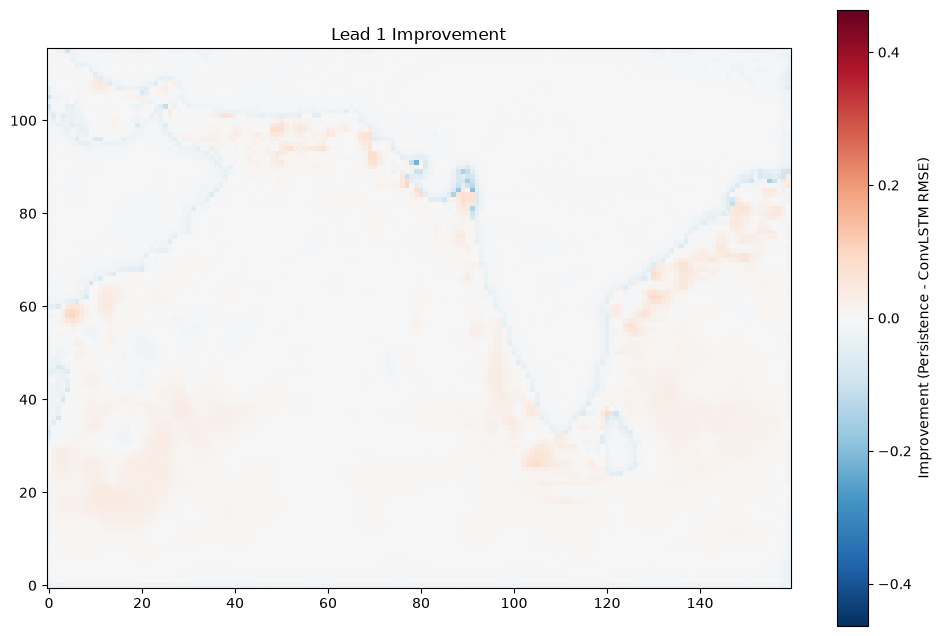

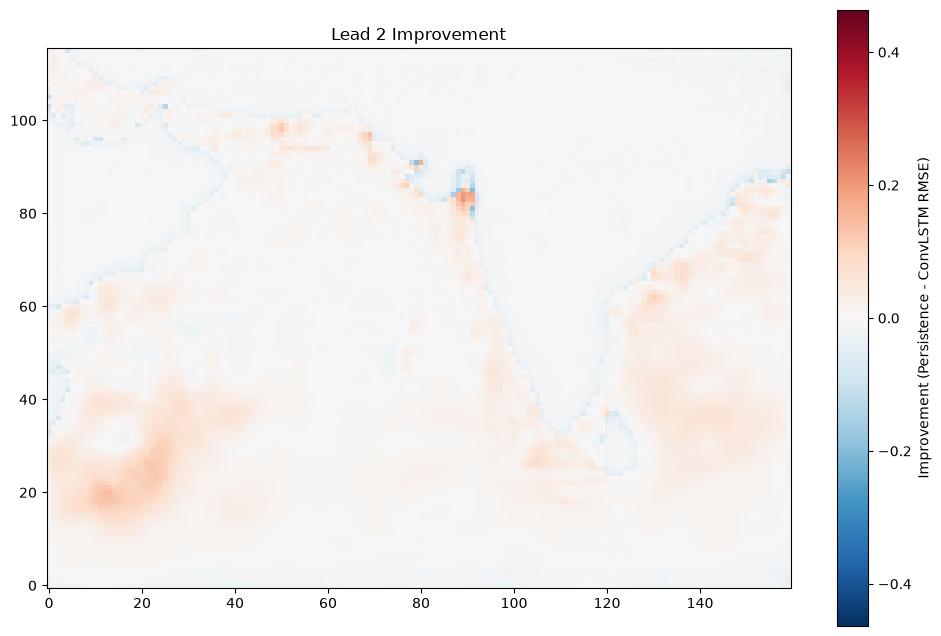

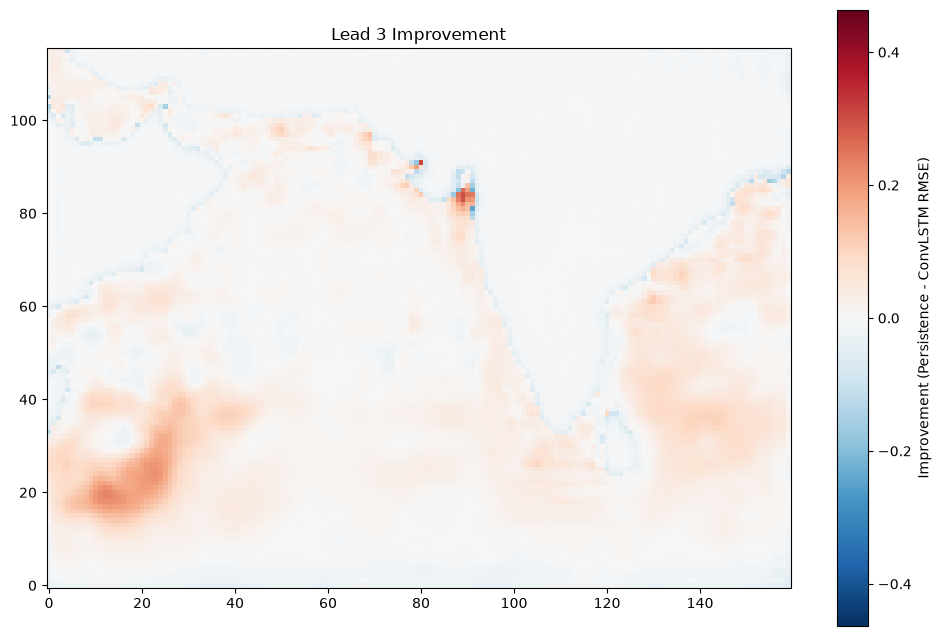

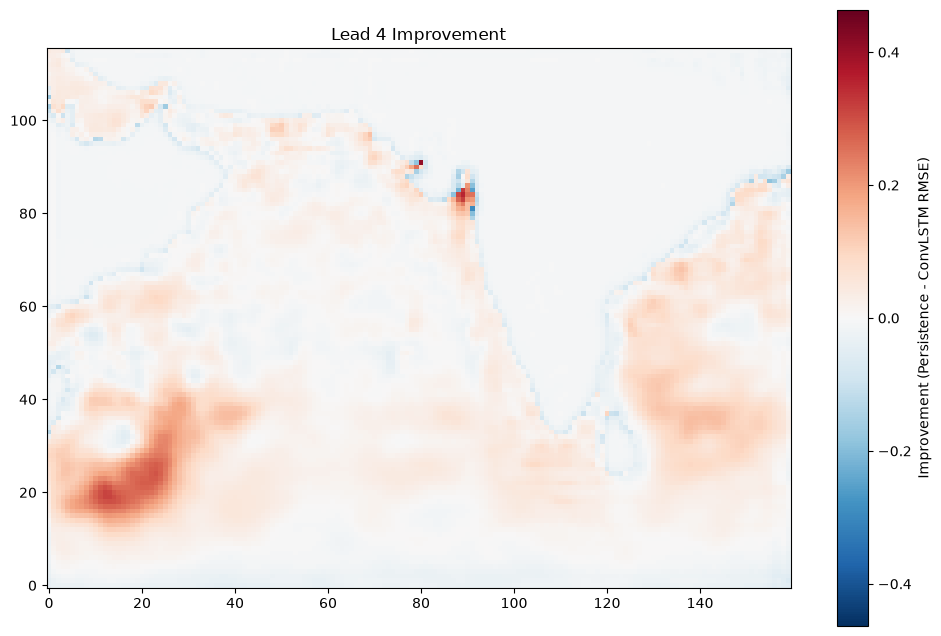

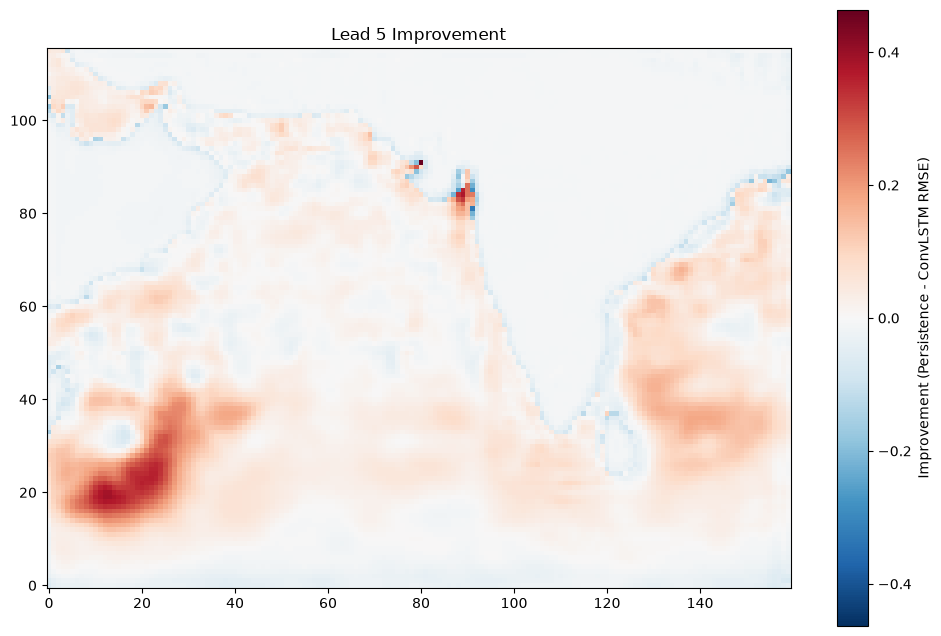

In [61]:
v = max(abs(m).max() for m in improvement_maps)

for lead in range(5):

    plt.figure(figsize=(12,8))

    plt.imshow(
        improvement_maps[lead],
        origin="lower",
        cmap="RdBu_r",
        vmin=-v,
        vmax=v
    )

    plt.colorbar(label="Improvement (Persistence - ConvLSTM RMSE)")

    plt.title(f"Lead {lead+1} Improvement")

    plt.show()